# Auswertung der Experimente (Datenexploration)
Dieses Notebook lädt die generierte CSV-Datei (`experiment_ergebnisse.csv`) und visualisiert die Ergebnisse für die Bachelorarbeit. 
Es generiert automatisch Publikations-bereite Graphen (mit 300 DPI für den Export) und berechnet die statistische Signifikanz.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Professionelles Design für die Bachelorarbeit (wie in wissenschaftlichen Papern)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 300, 'font.size': 12}) # 300 DPI für scharfen Export

csv_filename = "experiment_ergebnisse.csv"

if not os.path.exists(csv_filename):
    print(f"FEHLER: Die Datei {csv_filename} wurde nicht gefunden.")
else:
    # WICHTIG: Das Trennzeichen ist ein Semikolon, wie im Log-Skript definiert!
    df = pd.read_csv(csv_filename, sep=";")
    print(f"Daten erfolgreich geladen! Anzahl der durchgeführten Experimente: {len(df)}")
    display(df.head()) # Zeigt die ersten 5 Zeilen an

Daten erfolgreich geladen! Anzahl der durchgeführten Experimente: 83


,Datum/Uhrzeit,Seed,Target Dataset,Unknown Dataset,Samples pro Zielklasse,Anzahl Unknown Samples,Base_LR,Base_BatchSize,Strat_LR,Strat_BatchSize,...,Base_Recall,Base_F1_Score,Base_AUC_ROC,Strat_Accuracy,Strat_Balanced_Acc,Strat_Precision,Strat_Recall,Strat_F1_Score,Strat_AUC_ROC,Verbesserung_Acc
0,2026-08-18 12:01:39,42,PathMNIST,BloodMNIST,10,450,0.000158,16,0.000056,16,...,82.05,81.86,98.67,90.71,87.30,87.47,87.30,87.09,98.91,4.11
1,2026-08-18 12:46:12,100,PathMNIST,BloodMNIST,10,450,0.000220,16,0.000220,16,...,81.50,80.20,97.61,78.94,76.52,74.59,76.52,74.89,94.94,-5.42
2,2026-08-18 13:30:52,150,PathMNIST,BloodMNIST,10,450,0.000367,32,0.000280,32,...,84.06,84.36,97.60,86.30,79.49,83.63,79.49,79.89,93.37,-2.10
3,2026-08-18 14:13:03,42,PathMNIST,BloodMNIST,25,450,0.000158,16,0.000107,16,...,83.99,84.66,98.67,91.30,88.09,88.52,88.09,88.17,98.63,1.88
4,2026-08-18 14:58:01,100,PathMNIST,BloodMNIST,25,450,0.000220,16,0.000141,16,...,81.52,81.50,94.02,89.37,83.01,86.81,83.01,83.39,98.97,2.42



--- AUSWERTUNG FÜR N=50 (Anzahl Durchläufe: 54) ---


Mean                  Std          
Modell         Baseline  Strategie  Baseline Strategie
Metrik                                                
AUC_ROC       98.592778  98.604815  0.872789  0.786436
Accuracy      90.540370  91.254259  1.328272  1.629253
Balanced_Acc  86.634630  87.176296  2.315425  2.582448
F1_Score      86.549630  87.190556  2.143190  2.424180

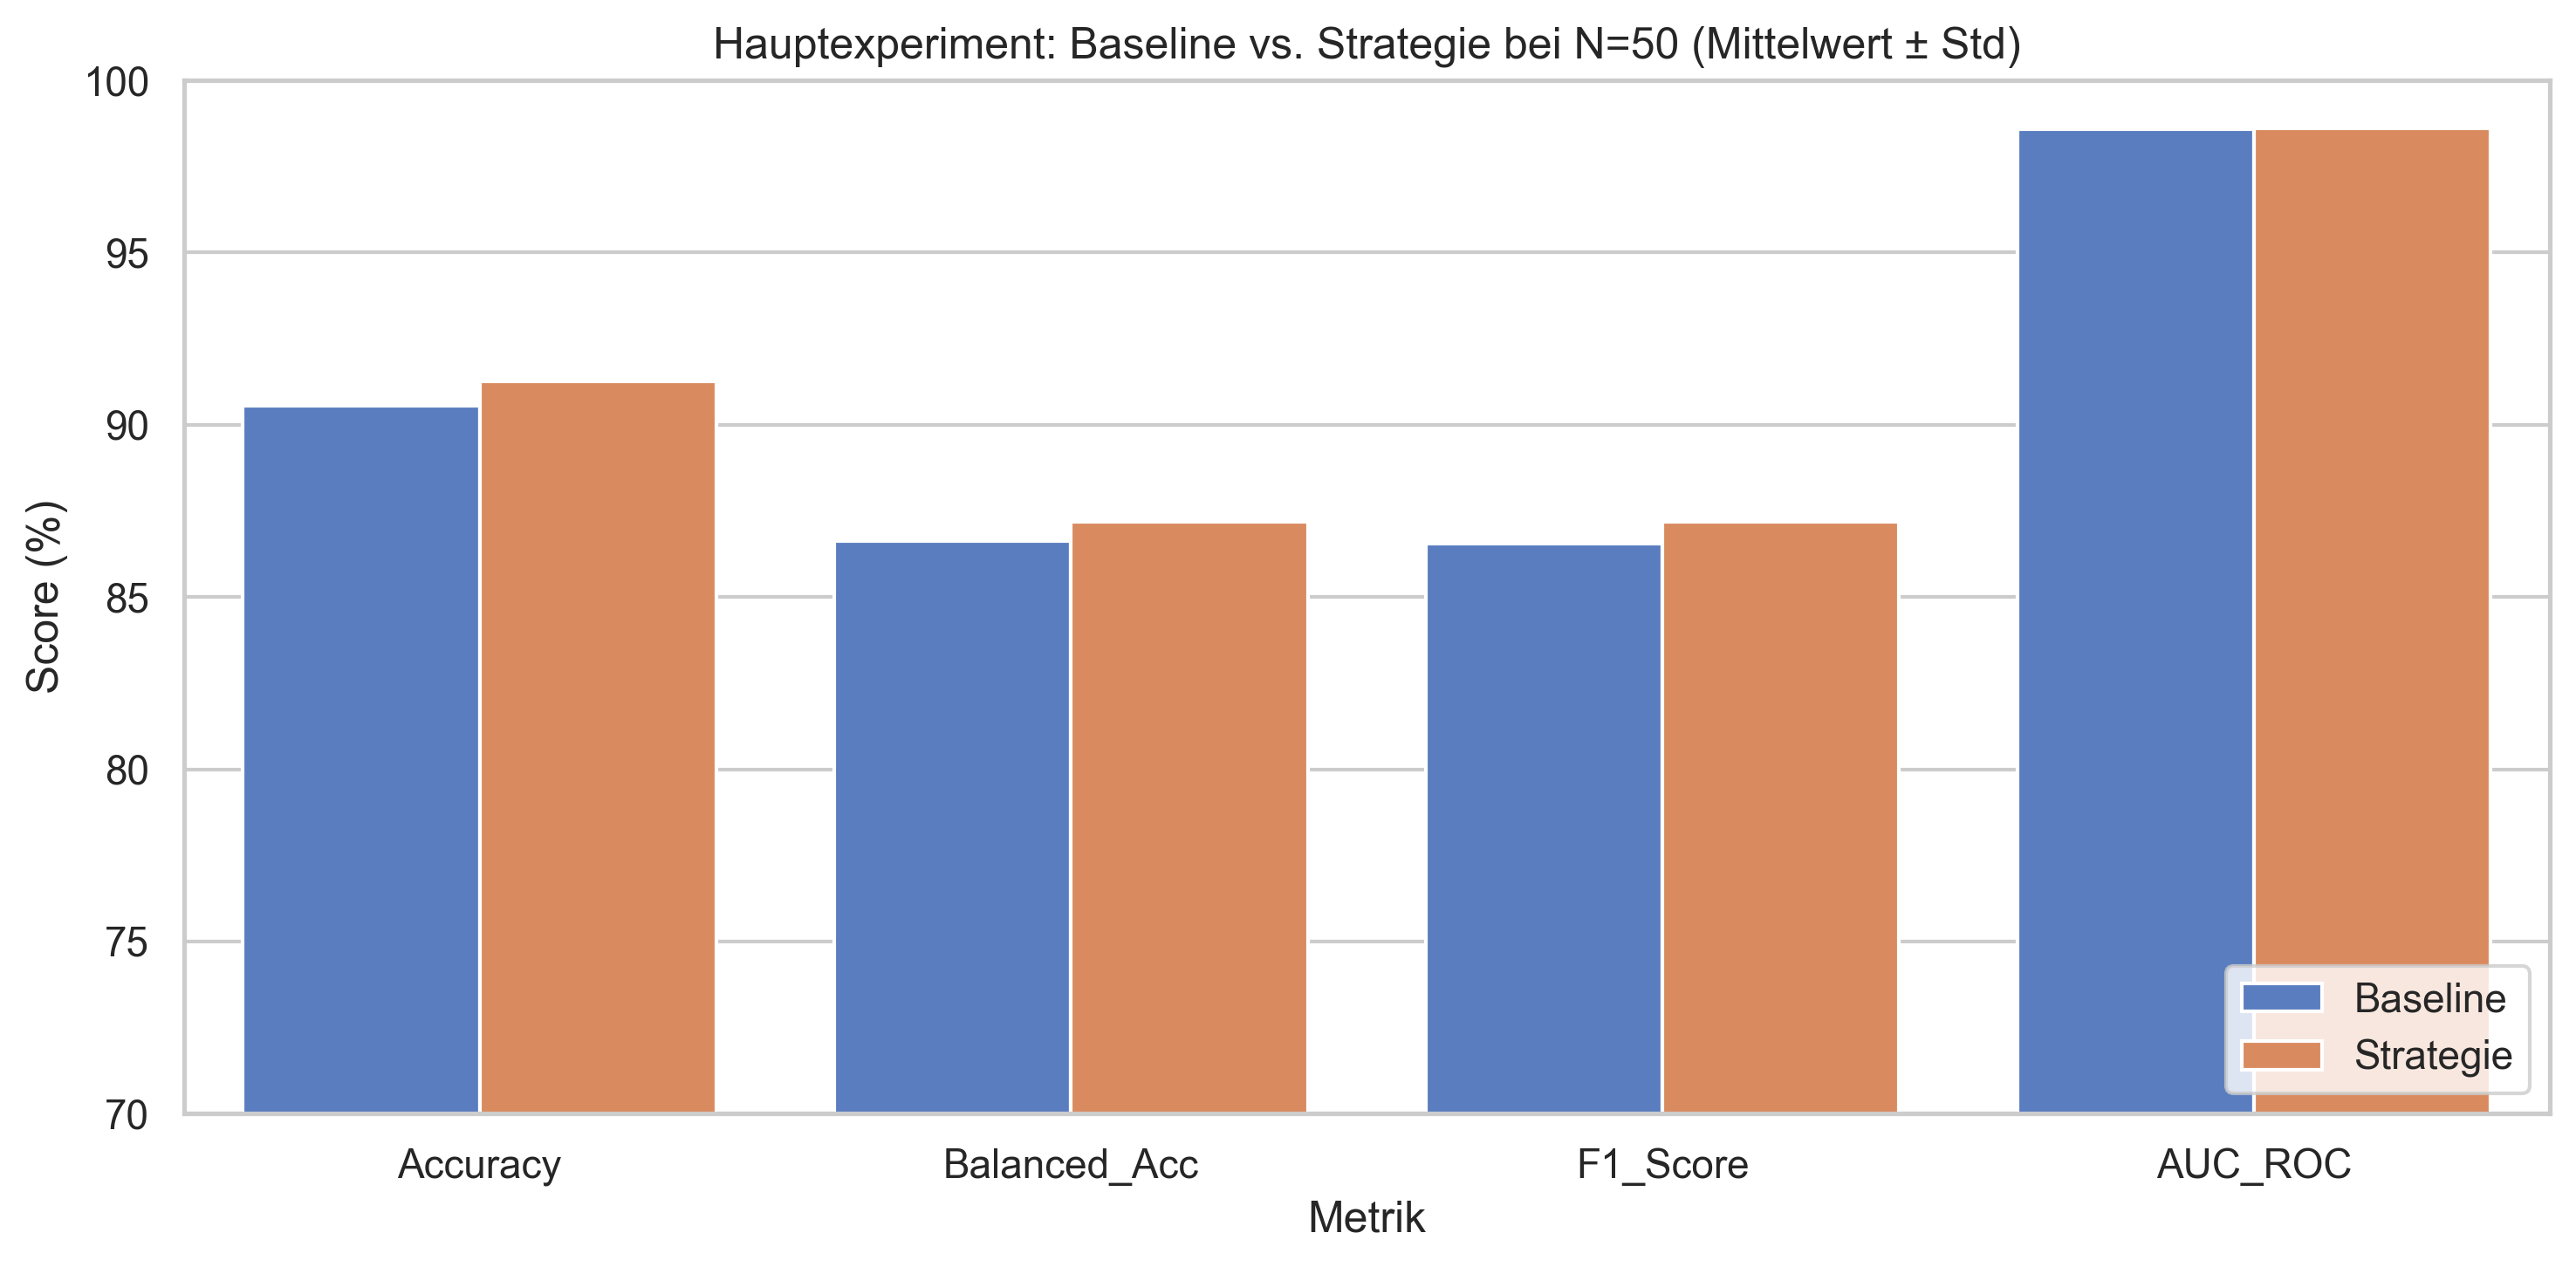

In [2]:
# ==========================================
# 1. HAUPT-EXPERIMENT (N = 50): Tabelle & Barplot mit Fehlerbalken
# ==========================================
df_50 = df[df["Samples pro Zielklasse"] == 50].copy()

if len(df_50) > 0:
    print(f"\n--- AUSWERTUNG FÜR N=50 (Anzahl Durchläufe: {len(df_50)}) ---")
    
    # Metriken, die wir vergleichen wollen
    metrics = ["Accuracy", "Balanced_Acc", "F1_Score", "AUC_ROC"]
    
    summary_data = []
    for m in metrics:
        base_col = f"Base_{m}"
        strat_col = f"Strat_{m}"
        
        b_mean, b_std = df_50[base_col].mean(), df_50[base_col].std()
        s_mean, s_std = df_50[strat_col].mean(), df_50[strat_col].std()
        
        summary_data.append({"Metrik": m, "Modell": "Baseline", "Mean": b_mean, "Std": b_std})
        summary_data.append({"Metrik": m, "Modell": "Strategie", "Mean": s_mean, "Std": s_std})
        
    df_summary = pd.DataFrame(summary_data)
    
    # Schöne Tabelle für die Thesis ausgeben
    display(df_summary.pivot(index="Metrik", columns="Modell", values=["Mean", "Std"]))
    
    # Barplot mit Fehlerbalken (Standardabweichung) statt unübersichtlicher Punkte
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=df_summary, x="Metrik", y="Mean", hue="Modell", capsize=0.1, errorbar="sd")
    
    plt.title("Hauptexperiment: Baseline vs. Strategie bei N=50 (Mittelwert ± Std)")
    plt.ylabel("Score (%)")
    plt.ylim(70, 100) # Skala von 70% bis 100% für bessere Lesbarkeit
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("plot_hauptexperiment_barplot.png")
    plt.show()

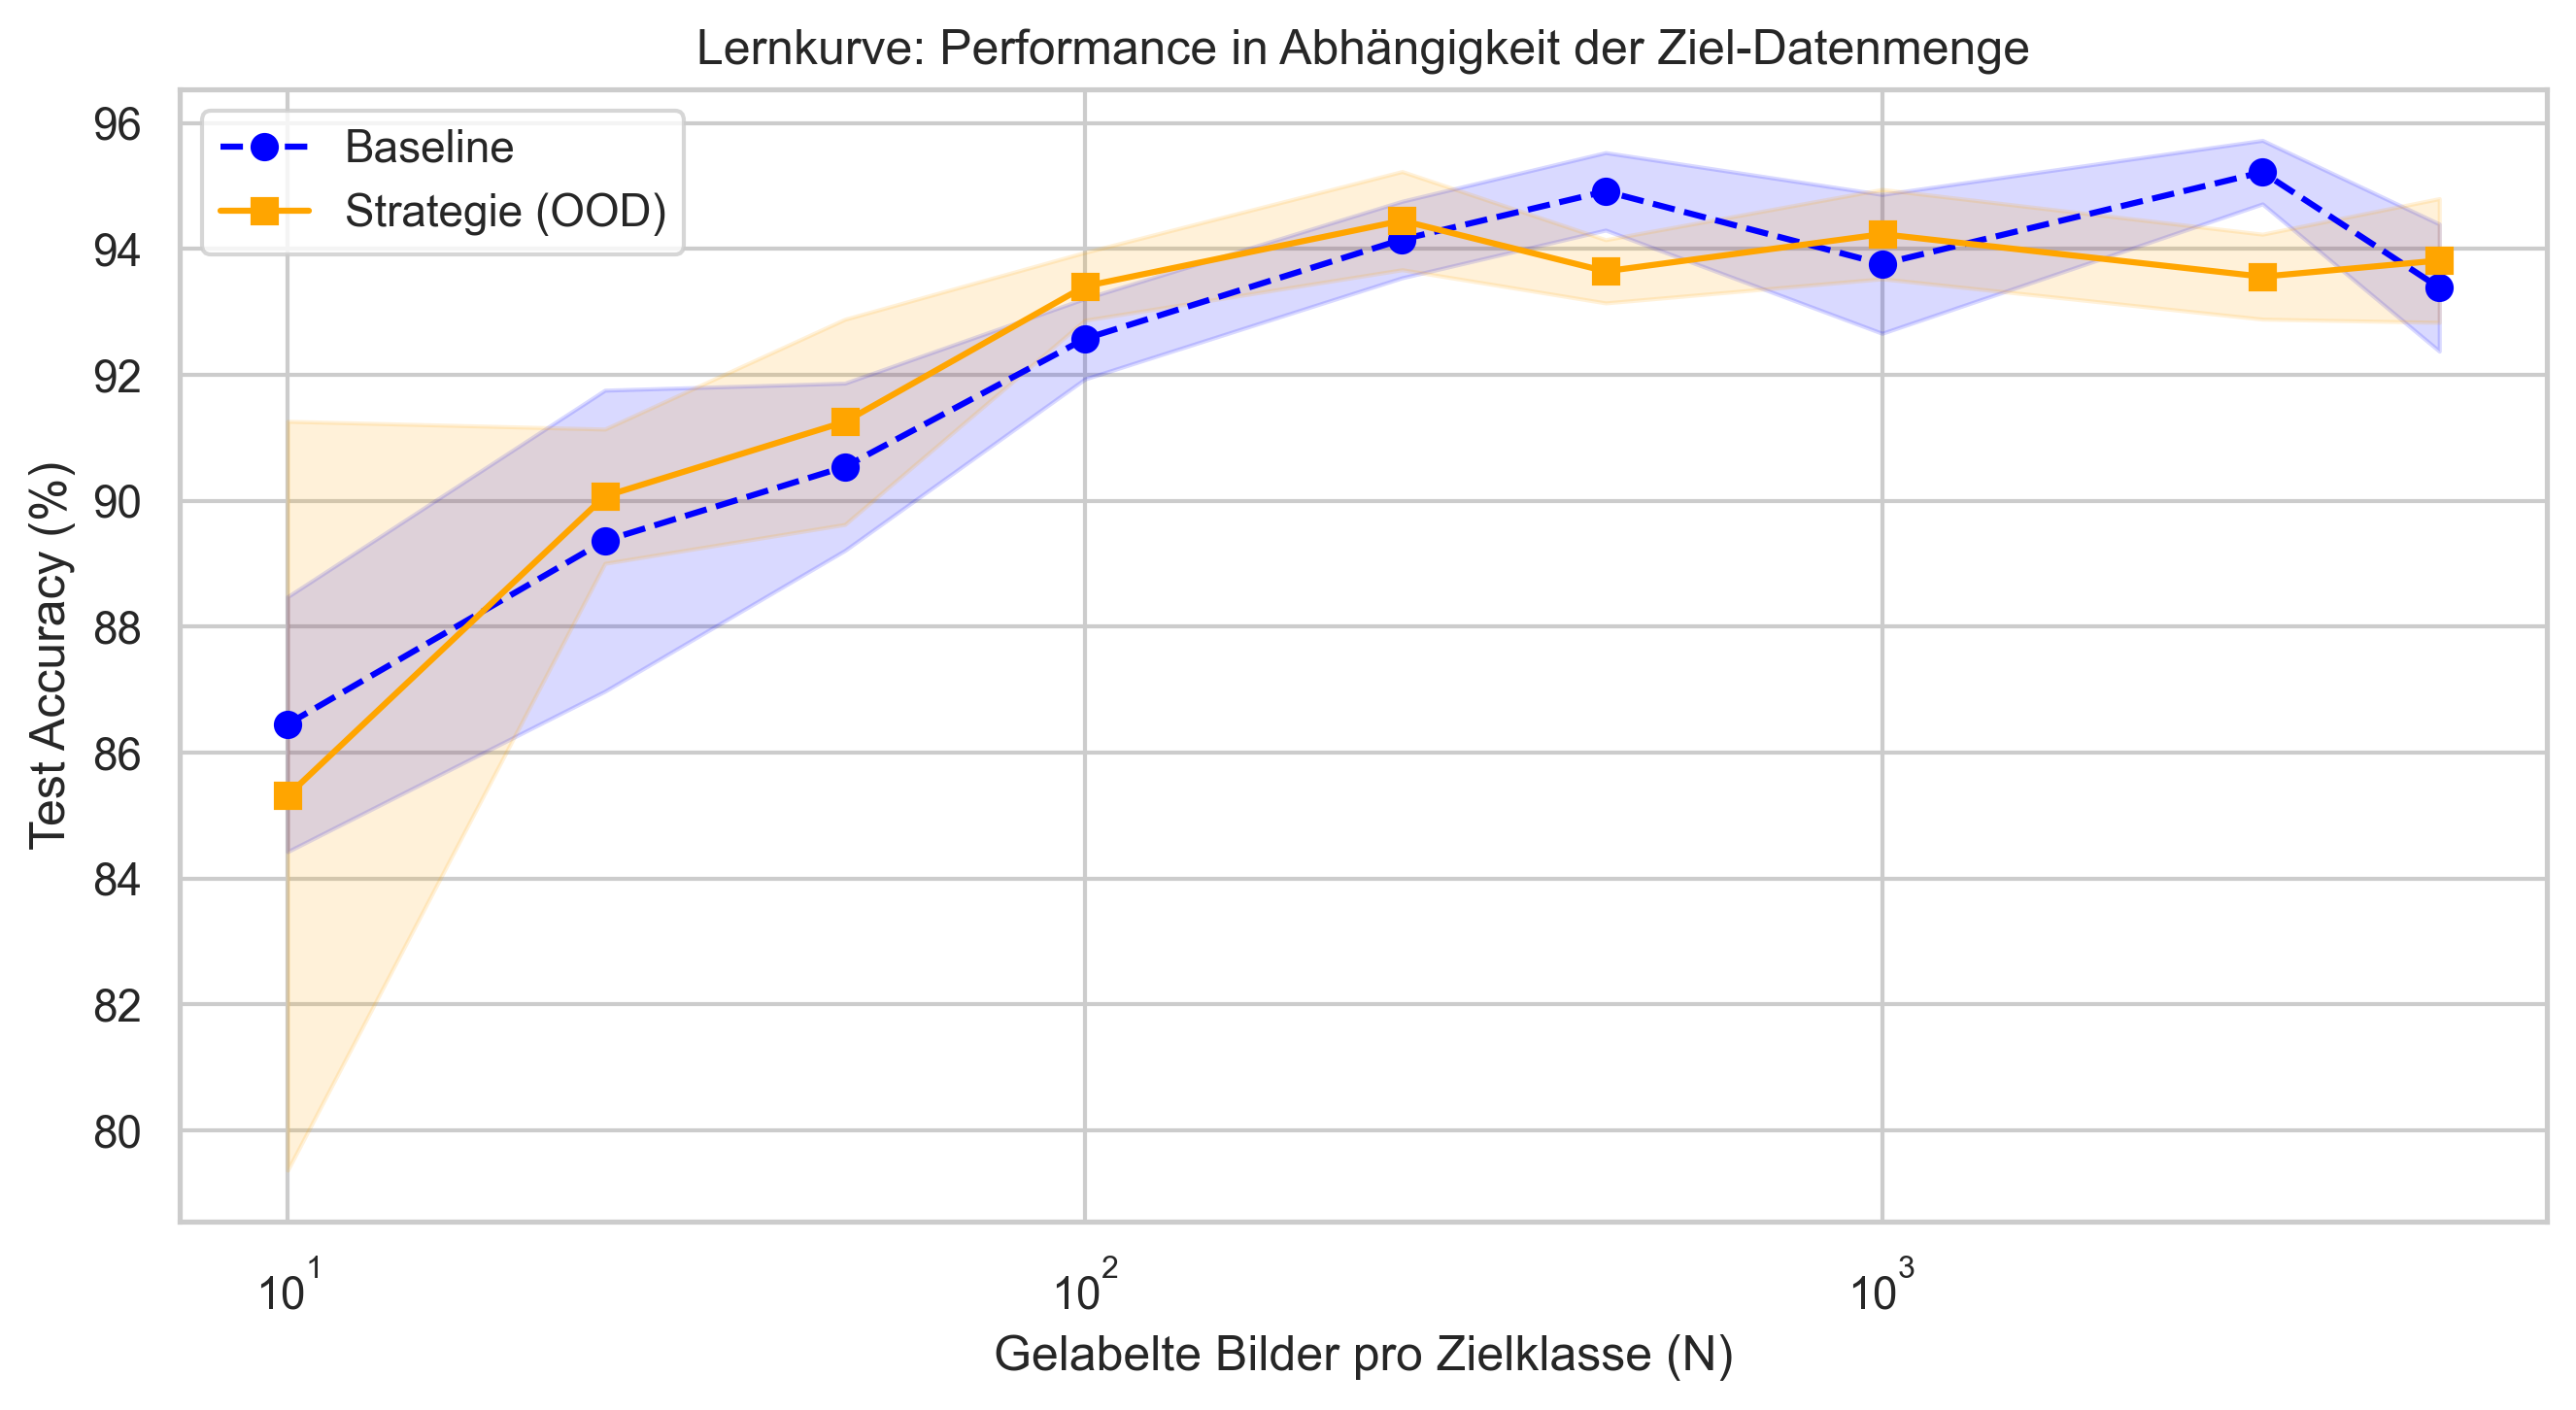

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

df = pd.read_csv("experiment_ergebnisse.csv", sep=";")
df_agg = df.groupby("Samples pro Zielklasse")[["Base_Accuracy", "Strat_Accuracy"]].agg(['mean', 'std']).reset_index()
df_agg.columns = ['N', 'Base_Mean', 'Base_Std', 'Strat_Mean', 'Strat_Std']

plt.figure(figsize=(9, 5))
# Baseline
plt.plot(df_agg["N"], df_agg["Base_Mean"], label="Baseline", marker="o", linestyle="--", color="blue")
plt.fill_between(df_agg["N"], df_agg["Base_Mean"] - df_agg["Base_Std"], df_agg["Base_Mean"] + df_agg["Base_Std"], color="blue", alpha=0.15)
# Strategie
plt.plot(df_agg["N"], df_agg["Strat_Mean"], label="Strategie (OOD)", marker="s", color="orange")
plt.fill_between(df_agg["N"], df_agg["Strat_Mean"] - df_agg["Strat_Std"], df_agg["Strat_Mean"] + df_agg["Strat_Std"], color="orange", alpha=0.15)

plt.title("Lernkurve: Performance in Abhängigkeit der Ziel-Datenmenge")
plt.xlabel("Gelabelte Bilder pro Zielklasse (N)")
plt.ylabel("Test Accuracy (%)")
plt.xscale('log') # Logarithmische Achse zeigt die kleinen N-Werte viel besser!
plt.legend()
plt.tight_layout()
plt.savefig("plot_lernkurve.png", dpi=300)
plt.show()

In [4]:
# ==========================================
# 3. STATISTISCHER SIGNIFIKANZ-TEST (für N=50)
# ==========================================
if len(df_50) >= 3:
    print("\n--- STATISTISCHER T-TEST (N=50) ---")
    t_stat, p_val = stats.ttest_rel(df_50["Strat_Accuracy"], df_50["Base_Accuracy"])
    print(f"p-Wert (Accuracy): {p_val:.5f}")
    if p_val < 0.05:
        print("Ergebnis: Der Unterschied ist statistisch signifikant (p < 0.05).")
    else:
        print("Ergebnis: Der Unterschied ist statistisch NICHT signifikant (p >= 0.05).")


--- STATISTISCHER T-TEST (N=50) ---
p-Wert (Accuracy): 0.00584
Ergebnis: Der Unterschied ist statistisch signifikant (p < 0.05).


Lade Datensätze für die Visualisierung...
Bild erfolgreich als 'dataset_comparison.png' gespeichert!


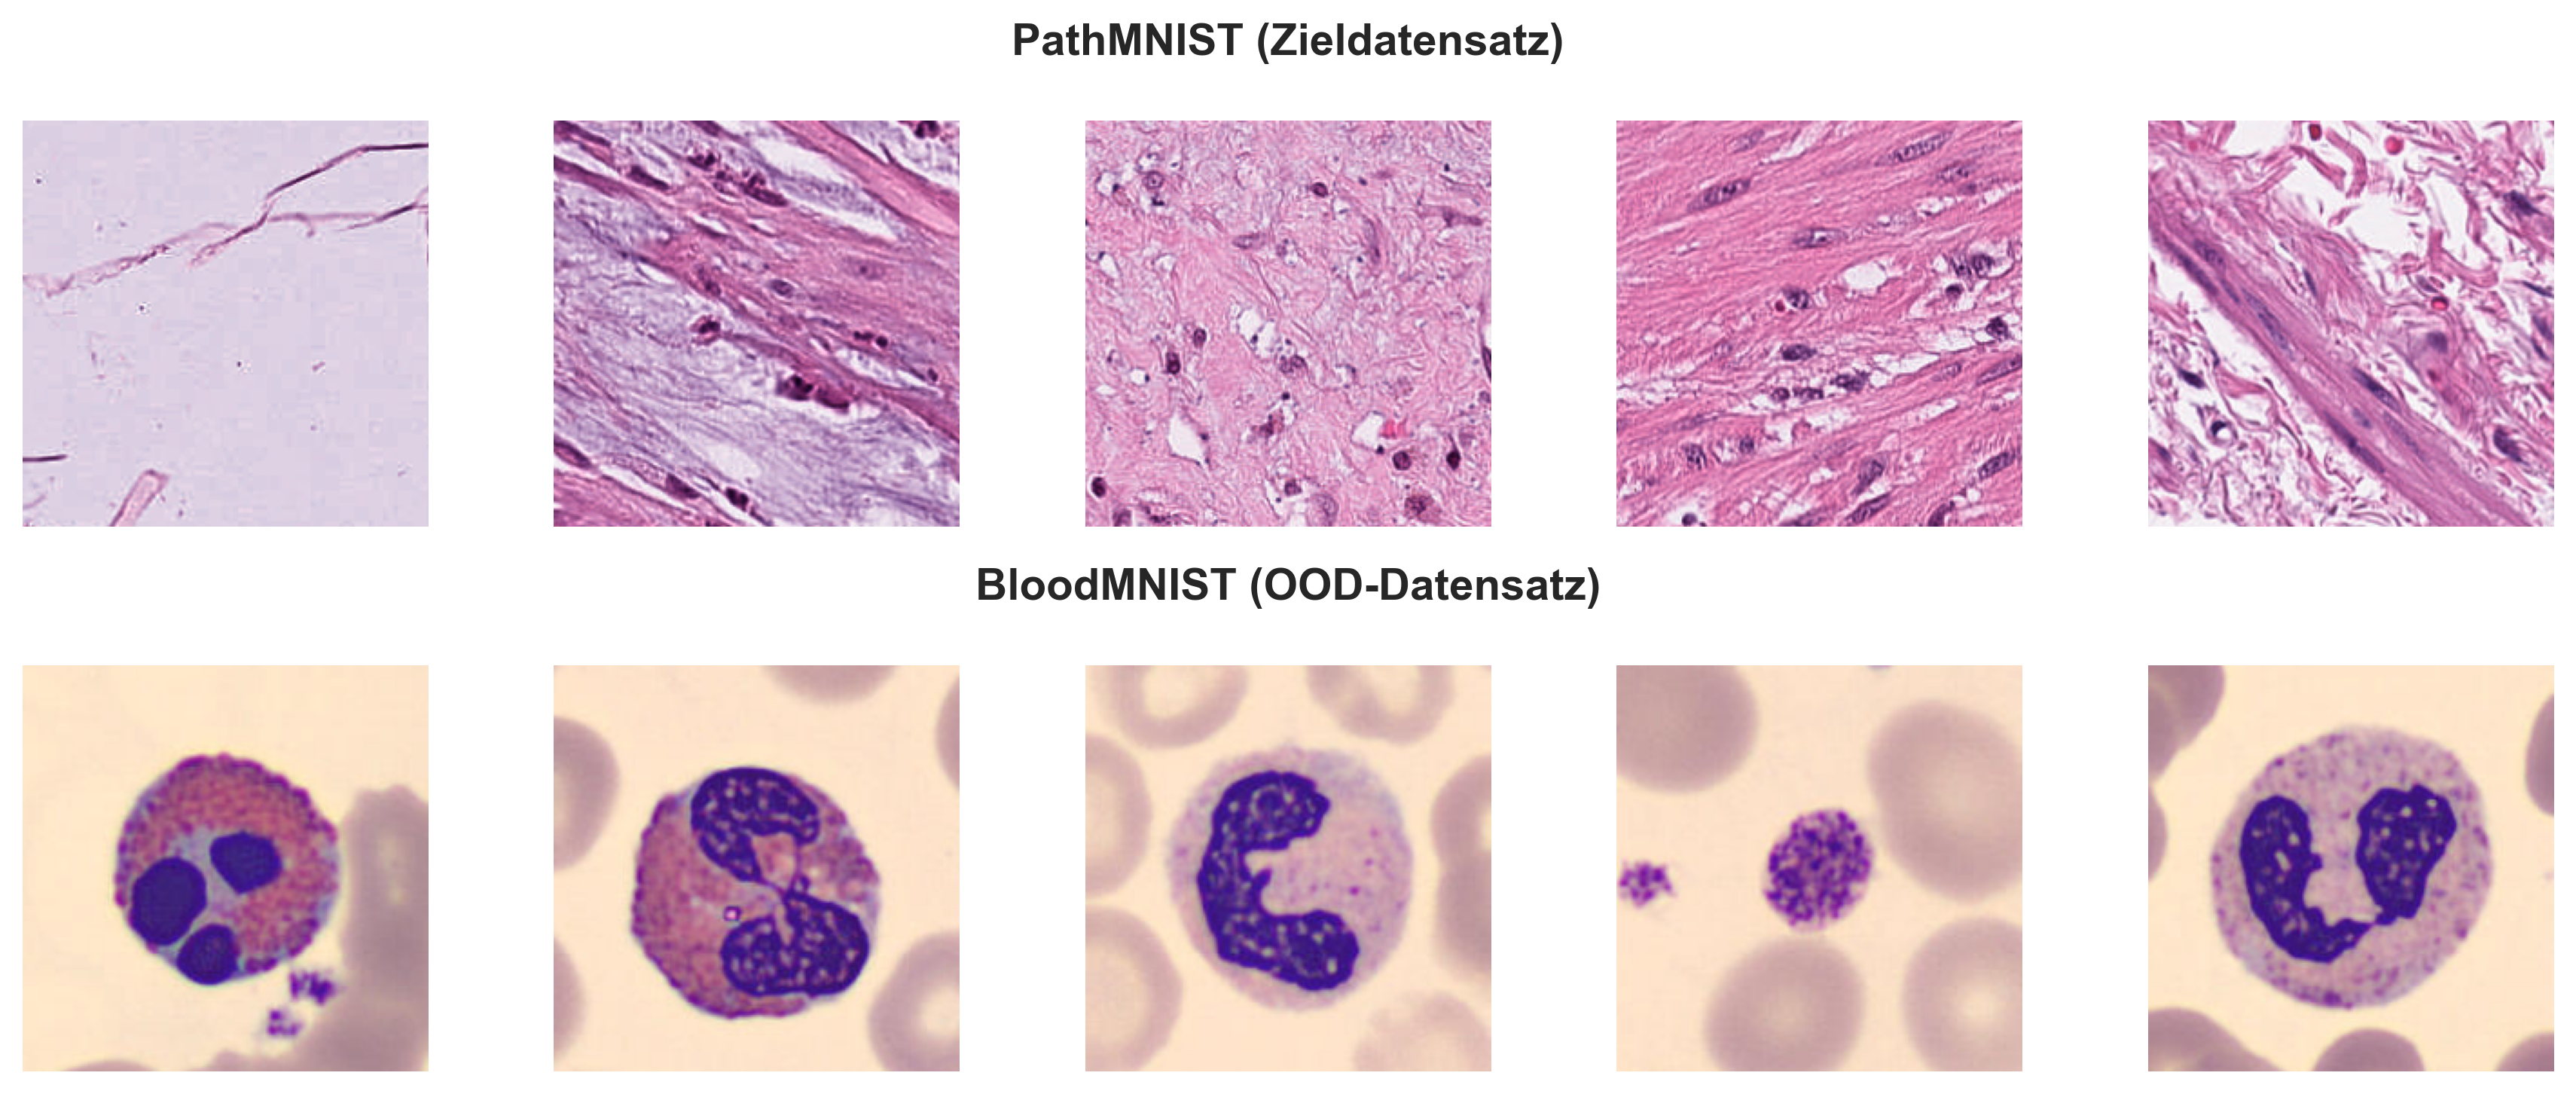

In [5]:
import matplotlib.pyplot as plt
from medmnist import PathMNIST, BloodMNIST

# 1. Datensätze laden 
# (Wir laden sie hier ohne Transformationen in der Originalgröße, 
# da Matplotlib direkt mit den rohen PIL-Bildern am besten arbeiten kann)
print("Lade Datensätze für die Visualisierung...")
path_ds = PathMNIST(split='train', download=False, size=224)
blood_ds = BloodMNIST(split='train', download=False, size=224)

# 2. Plot vorbereiten: 2 Reihen, 5 Spalten
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# 3. Obere Reihe: 5 Bilder aus PathMNIST
for i in range(5):
    img, label = path_ds[i] # Zieht das i-te Bild
    axes[0, i].imshow(img)
    axes[0, i].axis('off') # Schaltet die störenden Pixel-Achsen ab
    
    # Titel mittig über die Reihe setzen
    if i == 2:
        axes[0, i].set_title("PathMNIST (Zieldatensatz)\n", fontsize=14, fontweight='bold')

# 4. Untere Reihe: 5 Bilder aus BloodMNIST
# (Wir fangen bei Bild 10 an, da dort visuell oft schöne Blutzellen liegen)
offset = 10 
for i in range(5):
    img, label = blood_ds[i + offset]
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    
    if i == 2:
        axes[1, i].set_title("BloodMNIST (OOD-Datensatz)\n", fontsize=14, fontweight='bold')

# 5. Layout optimieren und in hoher Qualität (300 dpi) speichern
plt.subplots_adjust(hspace=0.5) # Sorgt für deutlichen Abstand zwischen den Zeilen
plt.savefig("dataset_comparison.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.savefig("dataset_comparison.png", dpi=300, bbox_inches='tight')
print("Bild erfolgreich als 'dataset_comparison.png' gespeichert!")

# Im Notebook anzeigen
plt.show()

Diagramm erfolgreich erstellt und als 'plot_ablation_mit_seeds_neu.png' gespeichert!


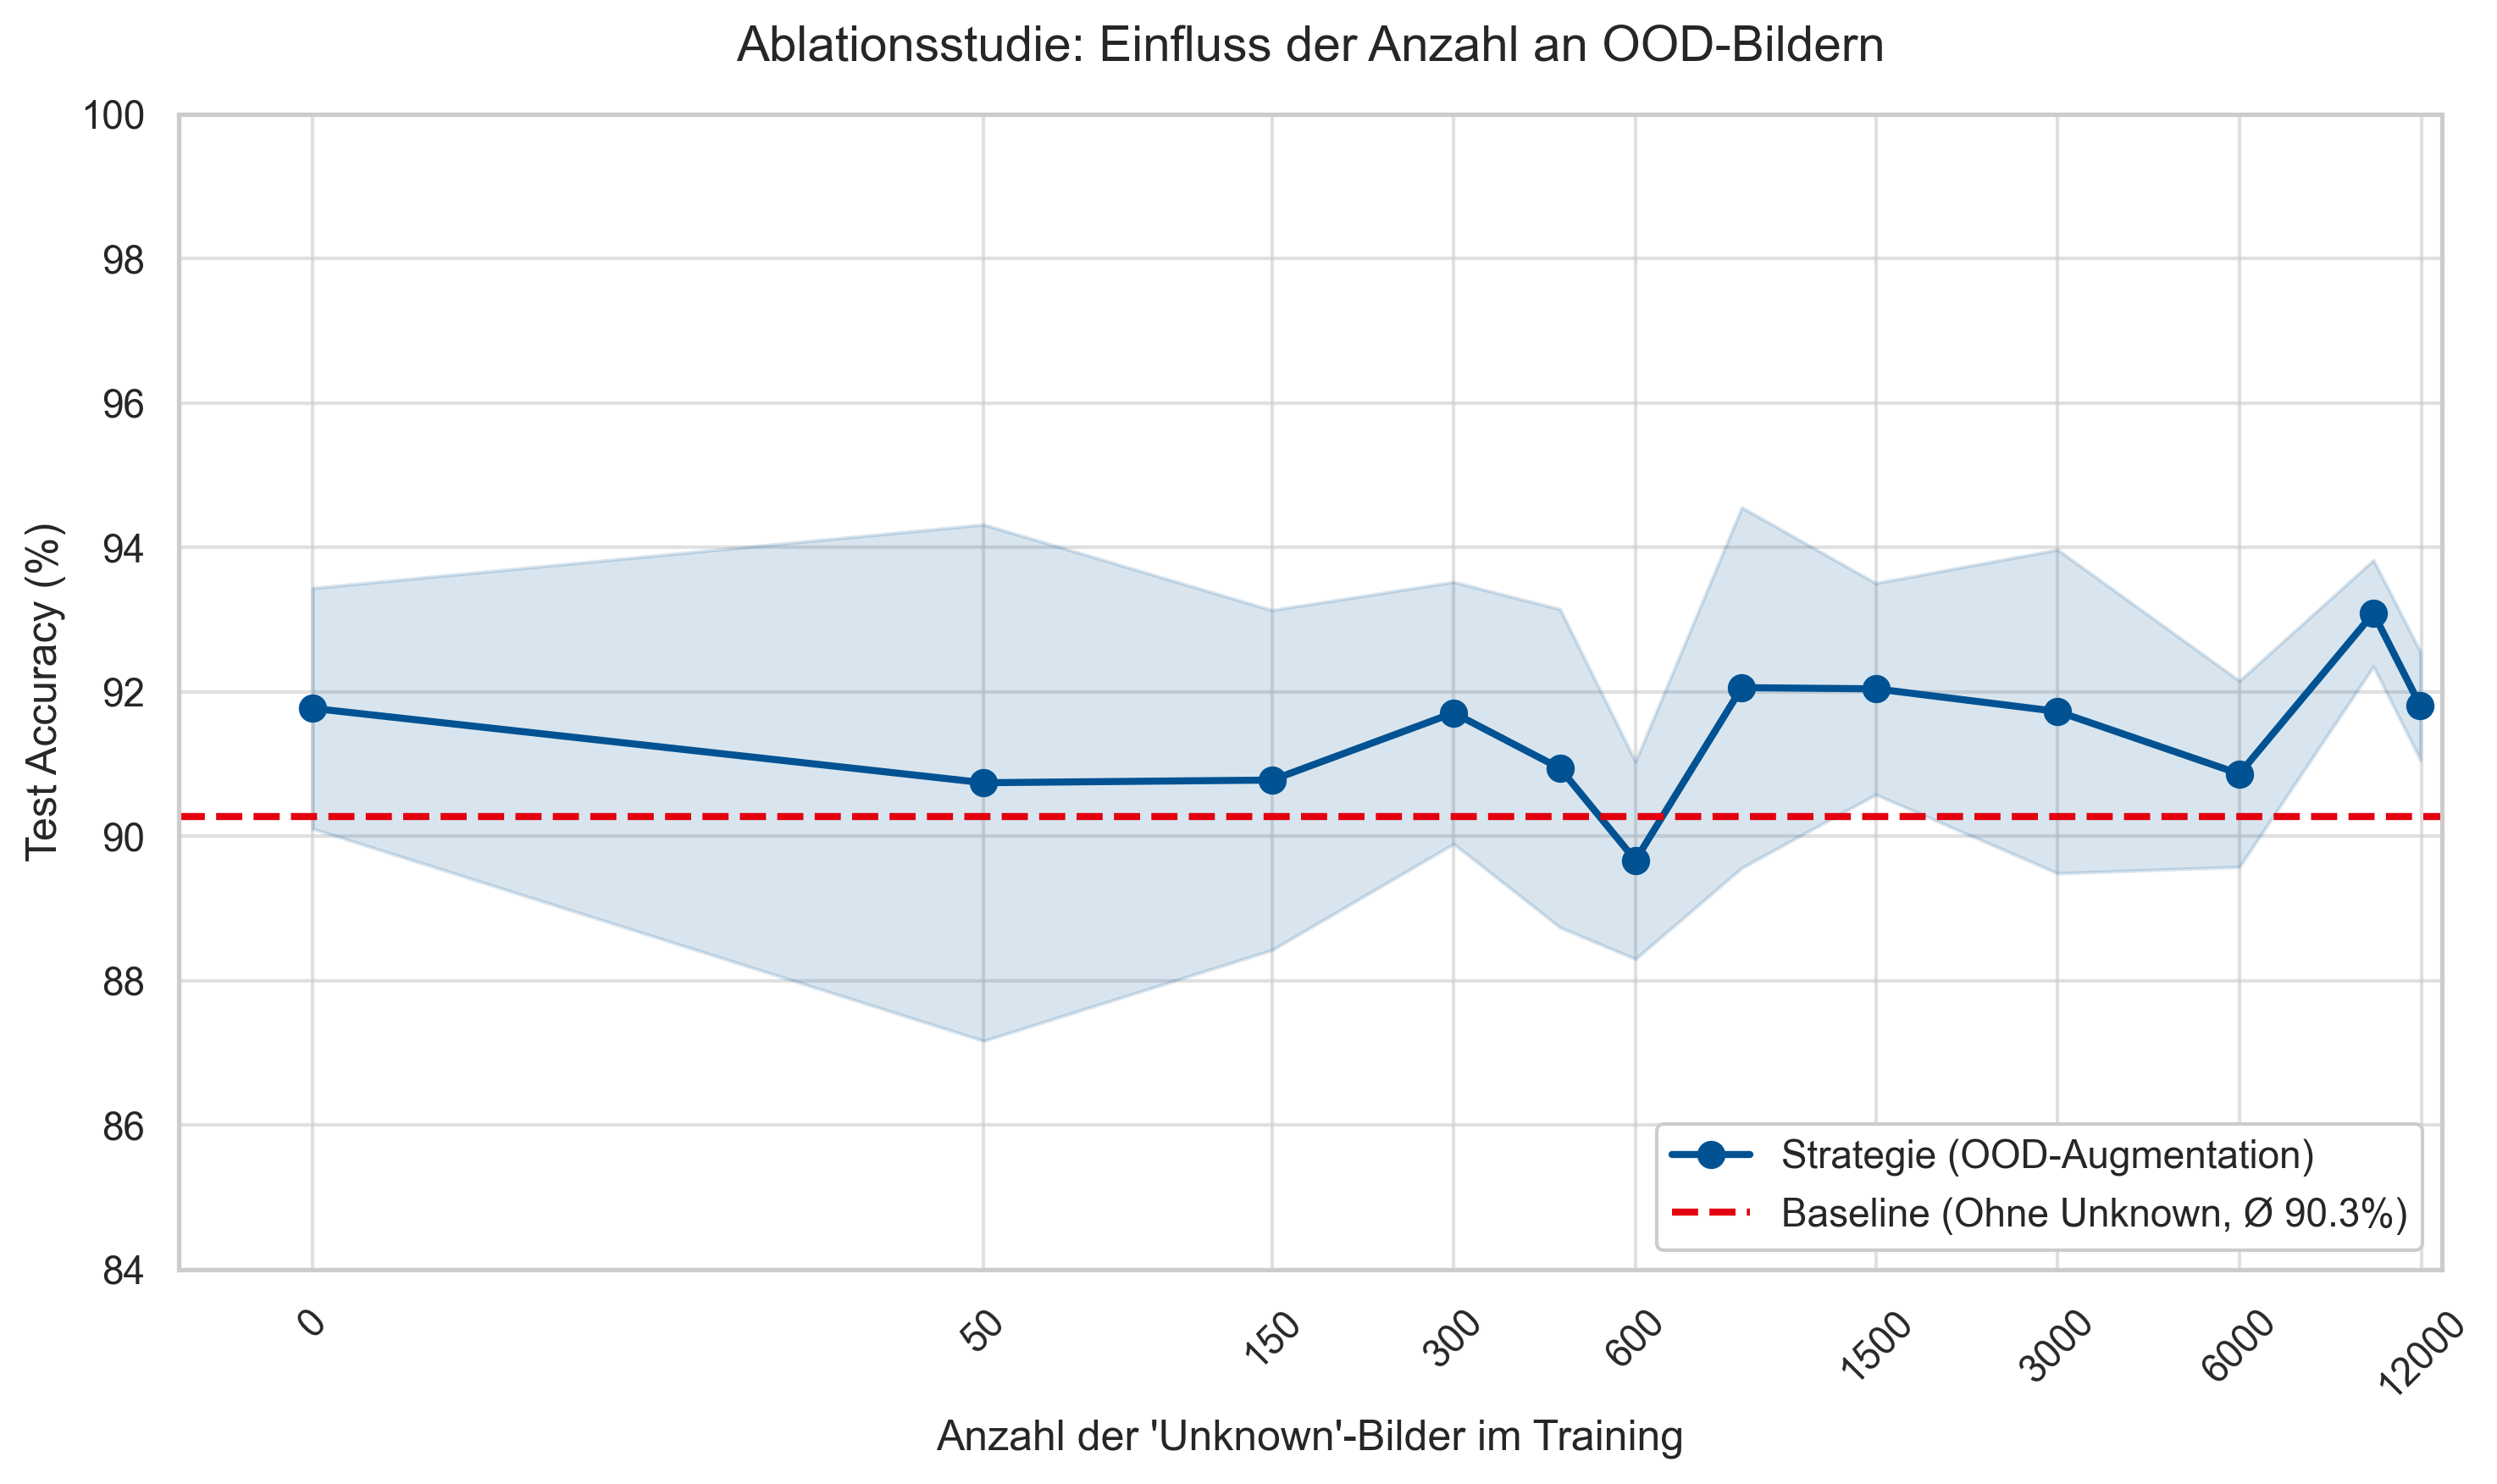

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.ticker import ScalarFormatter # NEU: Für normale Zahlen statt 10^2

# Design für die Bachelorarbeit einstellen
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 300, 'font.size': 12})

csv_filename = "experiment_ergebnisse_unknown.csv"

if not os.path.exists(csv_filename):
    print("Die CSV-Datei wurde nicht gefunden.")
else:
    df = pd.read_csv(csv_filename, sep=";")
    
    # Filtern auf N=50
    df_ablation = df[df["Samples pro Zielklasse"] == 50].copy()
    
    if len(df_ablation) > 0:
        # Mittelwert und Std berechnen
        df_agg = df_ablation.groupby("Anzahl Unknown Samples")[["Base_Accuracy", "Strat_Accuracy"]].agg(['mean', 'std']).reset_index()
        df_agg.columns = ['Unknown_Samples', 'Base_Mean', 'Base_Std', 'Strat_Mean', 'Strat_Std']
        
        plt.figure(figsize=(10, 6)) # Etwas breiter gemacht für die X-Achse
        
        # 1. Strategie-Kurve mit Schatten
        plt.plot(df_agg["Unknown_Samples"], df_agg["Strat_Mean"], 
                 label="Strategie (OOD-Augmentation)", marker="o", color="#005293", linewidth=2, markersize=7)
        plt.fill_between(df_agg["Unknown_Samples"], 
                         df_agg["Strat_Mean"] - df_agg["Strat_Std"], 
                         df_agg["Strat_Mean"] + df_agg["Strat_Std"], 
                         color="#005293", alpha=0.15)
        
        # 2. Baseline-Kurve
        base_total_mean = df_ablation["Base_Accuracy"].mean()
        plt.axhline(base_total_mean, color="#E3000F", linestyle="--", linewidth=2,
                    label=f"Baseline (Ohne Unknown, Ø {base_total_mean:.1f}%)")
        
        # Titel und Achsenbeschriftung
        plt.title("Ablationsstudie: Einfluss der Anzahl an OOD-Bildern", fontsize=14, pad=15)
        plt.xlabel("Anzahl der 'Unknown'-Bilder im Training", fontsize=12)
        plt.ylabel("Test Accuracy (%)", fontsize=12)
        
        # ==========================================
        # DER FIX FÜR DIE X-ACHSE
        # ==========================================
        plt.xscale('symlog', linthresh=50)
        plt.xlim(-10, 13000) # Schneidet den hässlichen, leeren Minus-Bereich ab!
        
        # Normale Zahlen statt wissenschaftlicher Notation (10^2)
        ax = plt.gca()
        ax.xaxis.set_major_formatter(ScalarFormatter())
        
        # Wir setzen explizit die Ticks, die Sinn machen
        custom_ticks = [0, 50, 150, 300, 600, 1500, 3000, 6000, 12000]
        ax.set_xticks(custom_ticks)
        
        # Leicht drehen, damit die Zahlen nicht ineinanderlaufen
        plt.xticks(rotation=45) 
        # ==========================================
        
        plt.legend(loc="lower right", framealpha=1.0)
        plt.ylim(84, 100) # Y-Achse
        
        # Gitterlinien etwas dezenter machen
        plt.grid(True, which="major", ls="-", alpha=0.6)
        
        plt.tight_layout()
        plt.savefig("plot_ablation_mit_seeds_neu.png")
        print("Diagramm erfolgreich erstellt und als 'plot_ablation_mit_seeds_neu.png' gespeichert!")
        plt.show()
    else:
        print("Keine Daten für Samples pro Zielklasse = 50 gefunden.")